# 11장 실습 — 스파이킹 오토인코더

**Spiking Neural Networks 쿡북 with Python** · 11장 실습 노트북

합성곱 스파이킹 오토인코더로 MNIST 이미지를 **압축했다 복원**한다(비지도 학습, 레이블 불필요).

### 학습 목표
- Conv–LIF 인코더와 ConvTranspose–LIF 디코더를 쌓는다.
- 마지막 스텝 막전위를 복원 이미지로 읽는다.
- 재구성 MSE 손실로 학습하고 결과를 시각화한다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate, utils
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0)
device = torch.device('cpu')
batch_size = 128

## 2. 데이터 준비 (MNIST)

28×28 흑백 이미지를 그대로 쓴다. 빠른 실습을 위해 일부만 사용한다.

In [2]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0,), (1,))])
train_dataset = datasets.MNIST('/tmp/data/mnist', train=True, download=True, transform=transform)
train_dataset = utils.data_subset(train_dataset, subset=20)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
print('학습 샘플 수:', len(train_dataset))

학습 샘플 수: 3000


## 3. 스파이킹 오토인코더 정의

인코더는 `Conv2d`(stride 2)로 28→14→7로 줄이고, 디코더는 `ConvTranspose2d`로 7→14→28로 키운다. `init_hidden=True`로 막전위를 자동 관리하고, 마지막 층 `output=True`로 막전위를 함께 받는다. `forward`는 `num_steps` 동안 순전파한 뒤 **마지막 스텝의 막전위**를 복원 이미지로 돌려준다.

In [3]:
beta = 0.9
spike_grad = surrogate.fast_sigmoid()
num_steps = 10

class SAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),                      # 28→14
            snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
            nn.Conv2d(16, 8, 3, stride=2, padding=1),                       # 14→7
            snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
            nn.ConvTranspose2d(8, 16, 3, stride=2, padding=1, output_padding=1),   # 7→14
            snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),   # 14→28
            snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True, output=True),
        )

    def forward(self, x):
        utils.reset(self.net)             # 막전위 초기화
        mem_rec = []
        for step in range(num_steps):
            spk, mem = self.net(x)
            mem_rec.append(mem)
        return mem_rec[-1]                # 마지막 스텝 막전위 = 복원 이미지

model = SAE().to(device)
print(model)

SAE(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Leaky()
    (2): Conv2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Leaky()
    (4): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Leaky()
    (6): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (7): Leaky()
  )
)


## 4. 재구성 학습 (MSE)

복원 이미지와 입력의 평균제곱오차를 줄인다. **레이블을 전혀 쓰지 않는** 비지도 학습이다.

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_hist = []

model.train()
for data, _ in train_loader:                 # 레이블은 무시
    data = data.to(device)
    recon = model(data)                      # 복원 이미지
    loss_val = F.mse_loss(recon, data)       # 재구성 손실
    optimizer.zero_grad()
    loss_val.backward()
    optimizer.step()
    loss_hist.append(loss_val.item())
    print(f'재구성 손실: {loss_val.item():.4f}')

재구성 손실: 4.1082
재구성 손실: 4.0709
재구성 손실: 4.0554
재구성 손실: 4.0704
재구성 손실: 4.0319
재구성 손실: 4.0113
재구성 손실: 3.9522
재구성 손실: 3.9325
재구성 손실: 3.8999
재구성 손실: 3.8668
재구성 손실: 3.8759
재구성 손실: 3.8424
재구성 손실: 3.8268
재구성 손실: 3.7569
재구성 손실: 3.7790
재구성 손실: 3.7541
재구성 손실: 3.7225
재구성 손실: 3.6883
재구성 손실: 3.6287
재구성 손실: 3.5749
재구성 손실: 3.5396
재구성 손실: 3.5047
재구성 손실: 3.4418


## 5. 손실 곡선과 복원 결과

입력(위)과 복원(아래) 이미지를 나란히 비교한다.

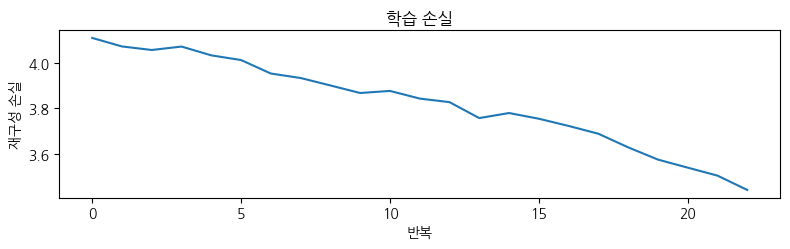

In [5]:
plt.figure(figsize=(8, 2.6)); plt.plot(loss_hist, color='tab:blue')
plt.xlabel('반복'); plt.ylabel('재구성 손실'); plt.title('학습 손실'); plt.tight_layout(); plt.show()

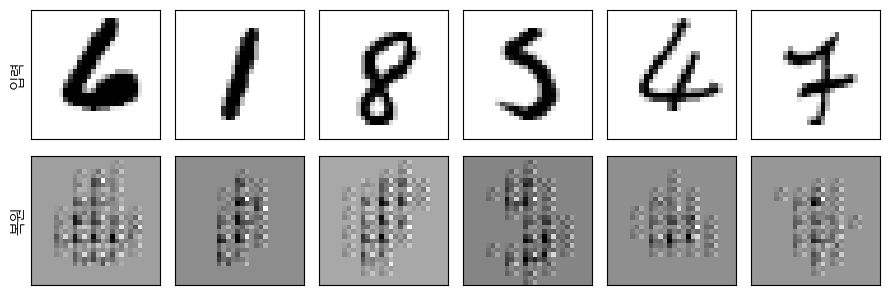

In [6]:
model.eval()
data, _ = next(iter(train_loader))
with torch.no_grad():
    recon = model(data.to(device))

fig, axs = plt.subplots(2, 6, figsize=(9, 3.2))
for j in range(6):
    axs[0, j].imshow(data[j, 0], cmap='binary'); axs[0, j].set_xticks([]); axs[0, j].set_yticks([])
    axs[1, j].imshow(recon[j, 0], cmap='binary'); axs[1, j].set_xticks([]); axs[1, j].set_yticks([])
axs[0, 0].set_ylabel('입력', fontsize=11)
axs[1, 0].set_ylabel('복원', fontsize=11)
plt.tight_layout(); plt.show()

## 정리

- 인코더(Conv)로 압축, 디코더(ConvTranspose)로 복원하는 스파이킹 오토인코더를 만들었다.
- 마지막 스텝 막전위를 복원 이미지로 읽었다(11장의 막전위 출력과 같은 방식).
- 재구성 MSE를 BPTT로 줄이며 레이블 없이 학습했다.

다음 12장에서는 출력 표현을 바꾸는 인구 코딩으로 분류 성능을 높인다.